# Step 1: Import Libraries

In [106]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# advanced model
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Step 2: Load Dataset

In [107]:
train = pd.read_csv("insurance/train.csv")
test = pd.read_csv("insurance/test.csv")

print(train.shape)
train.head()

(520000, 20)


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,1,52.0,NaN,NaN,Married,1.0,NaN,NaN,46.39,Suburban,Comprehensive,1.0,19.0,770.12,NaN,Good,Yes,Monthly,House,458.84
1,2,54.0,Male,20482.06,NaN,NaN,Master's,NaN,27.70,Suburban,NaN,1.0,NaN,704.13,5.0,Average,Yes,Weekly,Condo,200.05
2,3,27.0,Female,17775.08,Divorced,0.0,NaN,Self-Employed,29.28,Urban,Premium,0.0,12.0,NaN,1.0,Average,Yes,Weekly,NaN,223.93
3,4,47.0,Female,58531.02,Married,0.0,Bachelor's,Self-Employed,44.32,Urban,NaN,0.0,12.0,419.07,5.0,Good,No,Daily,NaN,278.17
4,5,38.0,Female,86930.27,Single,1.0,Master's,Self-Employed,68.03,Rural,Basic,1.0,14.0,650.90,9.0,Good,NaN,Daily,House,306.93


In [108]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520000 entries, 0 to 519999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    520000 non-null  int64  
 1   Age                   460257 non-null  float64
 2   Gender                489711 non-null  object 
 3   Annual Income         366970 non-null  float64
 4   Marital Status        386147 non-null  object 
 5   Number of Dependents  458033 non-null  float64
 6   Education Level       436067 non-null  object 
 7   Occupation            312415 non-null  object 
 8   Health Score          427827 non-null  float64
 9   Location              396667 non-null  object 
 10  Policy Type           459628 non-null  object 
 11  Previous Claims       491570 non-null  float64
 12  Vehicle Age           440458 non-null  float64
 13  Credit Score          436376 non-null  float64
 14  Insurance Duration    441736 non-null  float64
 15  

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,520000.000000,460257.000000,366970.000000,458033.000000,427827.000000,491570.000000,440458.000000,436376.000000,441736.000000,520000.000000
mean,260000.500000,48.259166,40851.926105,1.723590,28.854542,0.719708,7.829875,567.438356,4.983257,846.442148
std,150111.214327,11.763984,35960.673567,1.462789,14.027797,0.711268,5.593384,156.854662,2.640144,822.968422
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,278.220000,1.000000,0.000000
25%,130000.750000,39.000000,14525.732500,0.000000,16.720000,0.000000,3.000000,426.420000,3.000000,269.830000
50%,260000.500000,52.000000,29855.435000,1.000000,26.610000,1.000000,7.000000,574.230000,5.000000,524.275000
75%,390000.250000,57.000000,61401.357500,3.000000,40.330000,1.000000,12.000000,722.230000,7.000000,1217.242500
max,520000.000000,66.000000,154551.330000,4.000000,88.140000,4.000000,20.000000,859.790000,9.000000,4413.150000


# Step 3: Exploratory Data Analysis (EDA)

In [109]:
train.isnull().sum()

id                           0
Age                      59743
Gender                   30289
Annual Income           153030
Marital Status          133853
Number of Dependents     61967
Education Level          83933
Occupation              207585
Health Score             92173
Location                123333
Policy Type              60372
Previous Claims          28430
Vehicle Age              79542
Credit Score             83624
Insurance Duration       78264
Customer Feedback        89054
Smoking Status          100176
Exercise Frequency       68681
Property Type            80150
Premium Amount               0
dtype: int64

<Axes: xlabel='Premium Amount', ylabel='Count'>

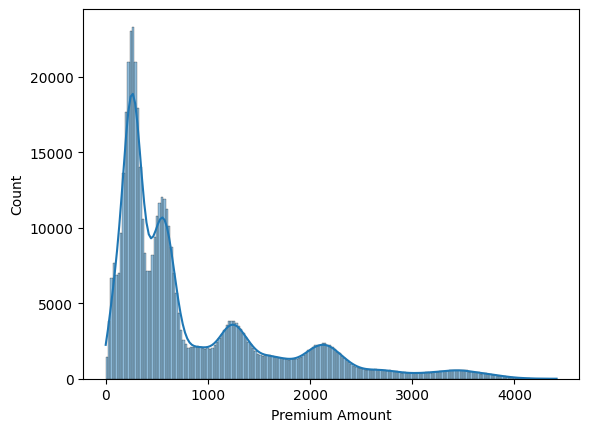

In [110]:
sns.histplot(train["Premium Amount"], kde=True)

# sttep 4:Data Cleaning


In [111]:
df = train.copy()
test_df = test.copy()

In [112]:
df = df.drop("id", axis=1)
test_ids = test_df["id"]
test_df = test_df.drop("id", axis=1)

In [113]:
# Log transformation to reduce skewness
df["Premium Amount"] = np.log1p(df["Premium Amount"])

In [114]:
# Impute missing values with median for numerical columns
num_cols = [
"Age",
"Annual Income",
"Number of Dependents",
"Health Score",
"Previous Claims",
"Vehicle Age",
"Credit Score",
"Insurance Duration"
]

for col in num_cols:
    median = df[col].median()

    df[col].fillna(median, inplace=True)
    test_df[col].fillna(median, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\197657405.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\197657405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

In [115]:
# Impute missing values with "Unknown" for categorical columns
cat_cols = [
"Gender",
"Marital Status",
"Education Level",
"Occupation",
"Location",
"Policy Type",
"Smoking Status",
"Exercise Frequency",
"Property Type"
]
for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)
    test_df[col].fillna("Unknown", inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\2782316943.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\2782316943.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [116]:
# Impute missing values with "No feedback" for "Customer Feedback"
df["Customer Feedback"].fillna("No feedback", inplace=True)
test_df["Customer Feedback"].fillna("No feedback", inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\2300380126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Customer Feedback"].fillna("No feedback", inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_217964\2300380126.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [117]:
# Remove outliers in "Previous Claims" using 99th percentile
q99 = df["Previous Claims"].quantile(0.99)

df = df[df["Previous Claims"] < q99]

In [118]:
q99 = df["Annual Income"].quantile(0.99)

df = df[df["Annual Income"] < q99]

In [119]:
df.isnull().sum()

Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Occupation              0
Health Score            0
Location                0
Policy Type             0
Previous Claims         0
Vehicle Age             0
Credit Score            0
Insurance Duration      0
Customer Feedback       0
Smoking Status          0
Exercise Frequency      0
Property Type           0
Premium Amount          0
dtype: int64

<Axes: xlabel='Premium Amount', ylabel='Count'>

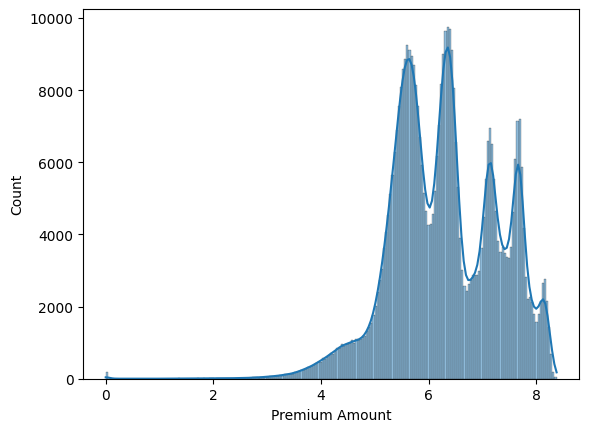

In [120]:
sns.histplot(df["Premium Amount"], kde=True)

# Step 5: Feature Engineering

In [121]:
df_fe = df.copy()
test_fe = test_df.copy()

In [122]:
# แปลงอายุเป็นกลุ่ม
bins = [18,30,40,50,60,100]
labels = [1,2,3,4,5]

df_fe["Age Group"] = pd.cut(df_fe["Age"], bins=bins, labels=labels)
test_fe["Age Group"] = pd.cut(test_fe["Age"], bins=bins, labels=labels)

In [123]:
# แปลงรายได้เป็นกลุ่ม
df_fe["Income Level"] = pd.qcut(df_fe["Annual Income"],4,labels=[1,2,3,4])
test_fe["Income Level"] = pd.qcut(test_fe["Annual Income"],4,labels=[1,2,3,4])

In [124]:
# สร้างฟีเจอร์ใหม่จากจำนวนผู้ติดตามและระยะเวลาประกัน
df_fe["Family Score"] = df_fe["Number of Dependents"] * df_fe["Insurance Duration"]
test_fe["Family Score"] = test_fe["Number of Dependents"] * test_fe["Insurance Duration"]

In [125]:
# combine health + lifestyle
df_fe["Health Risk"] = df_fe["Health Score"]

df_fe.loc[df_fe["Smoking Status"]=="Yes","Health Risk"] += 20
df_fe.loc[df_fe["Exercise Frequency"]=="Rarely","Health Risk"] += 10

test_fe["Health Risk"] = test_fe["Health Score"]

test_fe.loc[test_fe["Smoking Status"]=="Yes","Health Risk"] += 20
test_fe.loc[test_fe["Exercise Frequency"]=="Rarely","Health Risk"] += 10

In [126]:
# claim history มีผลกับ premium
df_fe["Claim Risk"] = df_fe["Previous Claims"] * df_fe["Vehicle Age"]
test_fe["Claim Risk"] = test_fe["Previous Claims"] * test_fe["Vehicle Age"]

In [127]:
# สร้างฟีเจอร์ใหม่จากเครดิตสกอร์และรายได้
df_fe["Financial Score"] = df_fe["Credit Score"] / (df_fe["Annual Income"] + 1)
test_fe["Financial Score"] = test_fe["Credit Score"] / (test_fe["Annual Income"] + 1)

In [128]:
# สร้างฟีเจอร์ใหม่จากรายได้และจำนวนผู้ติดตาม
df_fe["Income per Dependent"] = df_fe["Annual Income"] / (df_fe["Number of Dependents"] + 1)
test_fe["Income per Dependent"] = test_fe["Annual Income"] / (test_fe["Number of Dependents"] + 1)

In [129]:
# สร้างฟีเจอร์ใหม่จากอายุรถและประวัติการเคลม
df_fe["Vehicle Risk"] = df_fe["Vehicle Age"] * df_fe["Previous Claims"]
test_fe["Vehicle Risk"] = test_fe["Vehicle Age"] * test_fe["Previous Claims"]

In [130]:
# แปลงประเภทกรมธรรม์เป็นคะแนน
policy_map = {
"Basic":1,
"Comprehensive":2,
"Premium":3,
"Unknown":0
}

df_fe["Policy Score"] = df_fe["Policy Type"].map(policy_map)
test_fe["Policy Score"] = test_fe["Policy Type"].map(policy_map)

In [131]:
# สร้างฟีเจอร์ใหม่จากเครดิตสกอร์
df_fe["Credit Risk"] = 850 - df_fe["Credit Score"]
test_fe["Credit Risk"] = 850 - test_fe["Credit Score"]

In [132]:
# แปลงความถี่การออกกำลังกายเป็นคะแนน
exercise_map = {
"Daily":4,
"Weekly":3,
"Monthly":2,
"Rarely":1,
"Unknown":0
}

df_fe["Exercise Score"] = df_fe["Exercise Frequency"].map(exercise_map)
test_fe["Exercise Score"] = test_fe["Exercise Frequency"].map(exercise_map)

In [133]:
# แปลงสถานะการสูบบุหรี่เป็นตัวเลข
df_fe["Smoking Binary"] = (df_fe["Smoking Status"]=="Yes").astype(int)
test_fe["Smoking Binary"] = (test_fe["Smoking Status"]=="Yes").astype(int)

In [134]:
# สร้างฟีเจอร์ใหม่จากความยาวของคำติชม
df_fe["Feedback Length"] = df_fe["Customer Feedback"].str.len()
test_fe["Feedback Length"] = test_fe["Customer Feedback"].str.len()

In [135]:
# แปลงสถานที่อยู่อาศัยเป็นคะแนน
location_map = {
"Urban":3,
"Suburban":2,
"Rural":1,
"Unknown":0
}

df_fe["Location Score"] = df_fe["Location"].map(location_map)
test_fe["Location Score"] = test_fe["Location"].map(location_map)

In [136]:
# แปลงการศึกษาเป็นคะแนน
occupation_map = {
"Unemployed":3,
"Self-Employed":2,
"Employed":1,
"Unknown":0
}

df_fe["Occupation Risk"] = df_fe["Occupation"].map(occupation_map)
test_fe["Occupation Risk"] = test_fe["Occupation"].map(occupation_map)

In [137]:
# income + credit
df_fe["Income_Credit"] = df_fe["Annual Income"] * df_fe["Credit Score"]
test_fe["Income_Credit"] = test_fe["Annual Income"] * test_fe["Credit Score"]

# age + health
df_fe["Age_Health"] = df_fe["Age"] * df_fe["Health Score"]
test_fe["Age_Health"] = test_fe["Age"] * test_fe["Health Score"]

# claim frequency
df_fe["Claim Frequency"] = df_fe["Previous Claims"] / (df_fe["Insurance Duration"] + 1)
test_fe["Claim Frequency"] = test_fe["Previous Claims"] / (test_fe["Insurance Duration"] + 1)

# risk score
df_fe["Total Risk"] = (
    df_fe["Health Risk"] +
    df_fe["Claim Risk"] +
    df_fe["Credit Risk"]
)

test_fe["Total Risk"] = (
    test_fe["Health Risk"] +
    test_fe["Claim Risk"] +
    test_fe["Credit Risk"]
)

In [138]:
print(df_fe.shape)
df_fe.head()

(451072, 38)


,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,...,Credit Risk,Exercise Score,Smoking Binary,Feedback Length,Location Score,Occupation Risk,Income_Credit,Age_Health,Claim Frequency,Total Risk
0,52.0,Unknown,29855.435,Married,1.0,Unknown,Unknown,46.39,Suburban,Comprehensive,...,79.88,2,1,4,2,0,2.299227e+07,2412.28,0.166667,165.27
1,54.0,Male,20482.060,Unknown,1.0,Master's,Unknown,27.70,Suburban,Unknown,...,145.87,3,1,7,2,0,1.442203e+07,1495.80,0.166667,200.57
2,27.0,Female,17775.080,Divorced,0.0,Unknown,Self-Employed,29.28,Urban,Premium,...,275.77,3,1,7,3,2,1.020698e+07,790.56,0.000000,325.05
3,47.0,Female,58531.020,Married,0.0,Bachelor's,Self-Employed,44.32,Urban,Unknown,...,430.93,4,0,4,3,2,2.452859e+07,2083.04,0.000000,475.25
4,38.0,Female,86930.270,Single,1.0,Master's,Self-Employed,68.03,Rural,Basic,...,199.10,4,0,4,1,2,5.658291e+07,2585.14,0.100000,281.13


# Step 6: Encoding Categorical Features

In [139]:
df_fe.select_dtypes(include="object").columns

Index(['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location',
       'Policy Type', 'Customer Feedback', 'Smoking Status',
       'Exercise Frequency', 'Property Type'],
      dtype='object')

In [140]:
# ลบคอลัมน์ที่ไม่จำเป็น
df_fe = df_fe.drop("Customer Feedback", axis=1)
test_fe = test_fe.drop("Customer Feedback", axis=1)

In [141]:
X = df_fe.drop("Premium Amount", axis=1)
y = df_fe["Premium Amount"]

X_test = test_fe.copy()

In [142]:
cat_cols = X.select_dtypes(include="object").columns
print(cat_cols)

Index(['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location',
       'Policy Type', 'Smoking Status', 'Exercise Frequency', 'Property Type'],
      dtype='object')


In [143]:
import category_encoders as ce

cat_cols = X.select_dtypes(include="object").columns

encoder = ce.TargetEncoder(cols=cat_cols)

X[cat_cols] = encoder.fit_transform(X[cat_cols], y)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [144]:
cat_cols2 = X.select_dtypes(include="category").columns

for col in cat_cols2:
    X[col] = X[col].cat.codes
    X_test[col] = X_test[col].cat.codes

In [145]:
X.dtypes

Age                     float64
Gender                  float64
Annual Income           float64
Marital Status          float64
Number of Dependents    float64
Education Level         float64
Occupation              float64
Health Score            float64
Location                float64
Policy Type             float64
Previous Claims         float64
Vehicle Age             float64
Credit Score            float64
Insurance Duration      float64
Smoking Status          float64
Exercise Frequency      float64
Property Type           float64
Age Group                  int8
Income Level               int8
Family Score            float64
Health Risk             float64
Claim Risk              float64
Financial Score         float64
Income per Dependent    float64
Vehicle Risk            float64
Policy Score              int64
Credit Risk             float64
Exercise Score            int64
Smoking Binary            int64
Feedback Length           int64
Location Score            int64
Occupati

In [146]:
print(X.shape)
print(X_test.shape)

(451072, 36)
(80000, 36)


<Axes: >

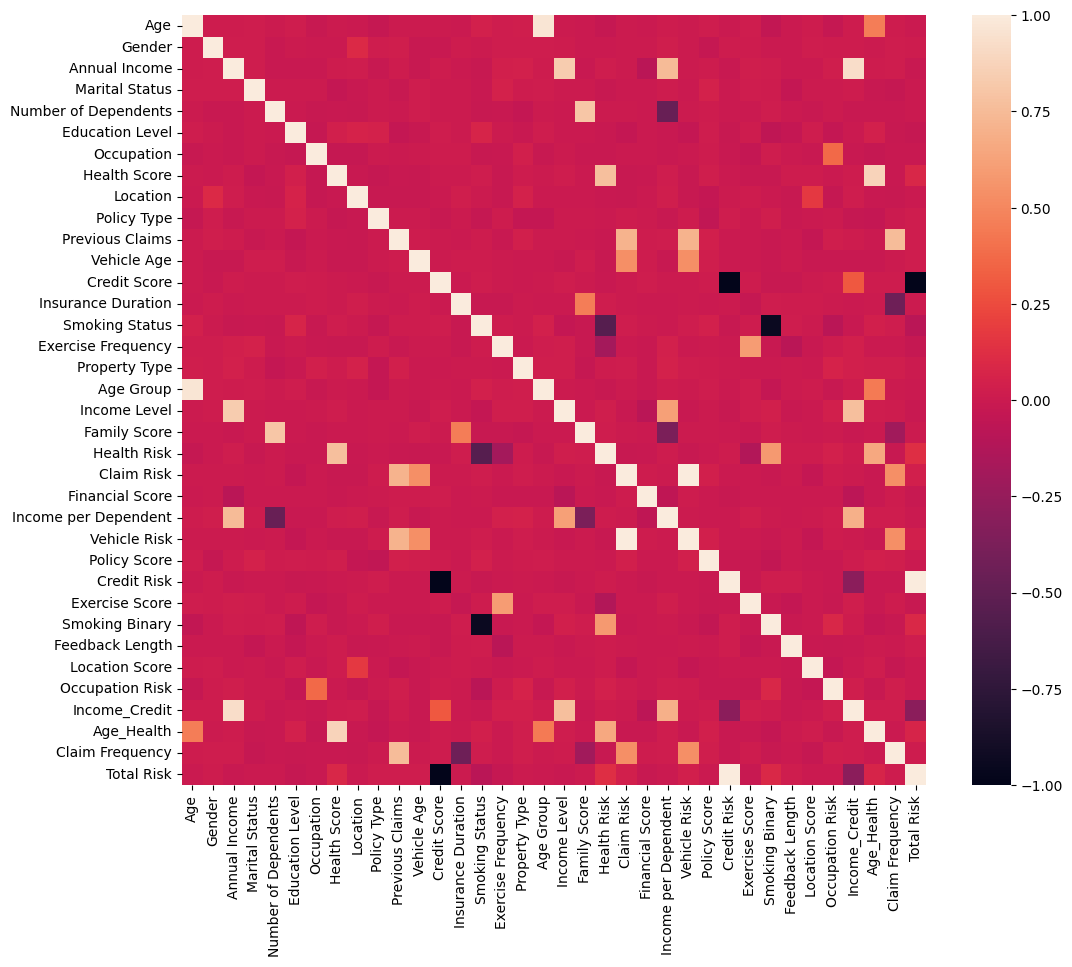

In [147]:
corr = X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)

# Step 7 : Train Validation + Cross Validation

In [148]:
print(X.shape)
print(X_test.shape)

(451072, 36)
(80000, 36)


In [149]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [150]:
oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

In [151]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

In [152]:
# parameters
lgb_params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.01,
    "n_estimators": 3000,
    "max_depth": 8,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

xgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.01,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42
}

cat_params = {
    "iterations": 3000,
    "learning_rate": 0.01,
    "depth": 8,
    "loss_function": "MAE",
    "random_state": 42,
    "verbose": 0
}

In [153]:
X.select_dtypes(include="object")

""
0
1
2
3
4
...
519994
519995
519996
519997


In [154]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print("Fold:", fold+1)

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Models
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    xgb_model = xgb.XGBRegressor(**xgb_params)
    cat_model = cb.CatBoostRegressor(**cat_params)

    # Train
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(200),
            lgb.log_evaluation(200)
        ]
    )

    xgb_model.fit(X_train, y_train)

    cat_model.fit(X_train, y_train)

    # Validation prediction
    lgb_val = lgb_model.predict(X_val)
    xgb_val = xgb_model.predict(X_val)
    cat_val = cat_model.predict(X_val)

    # Ensemble
    val_pred = (
        0.4 * lgb_val +
        0.3 * xgb_val +
        0.3 * cat_val
    )

    oof_pred[val_idx] = val_pred

    # Test prediction
    lgb_test = lgb_model.predict(X_test)
    xgb_test = xgb_model.predict(X_test)
    cat_test = cat_model.predict(X_test)

    test_pred += (
        0.4 * lgb_test +
        0.3 * xgb_test +
        0.3 * cat_test
    ) / kf.n_splits

Fold: 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2795
[LightGBM] [Info] Number of data points in the train set: 405964, number of used features: 36
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 6.290352
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 0.791407
[400]	valid_0's l1: 0.790338
[600]	valid_0's l1: 0.789877
[800]	valid_0's l1: 0.789734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1000]	valid_0's l1: 0.789721
Early stopping, best iteration is:
[897]	valid_0's l1: 0.789696
Fold: 2
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threadi

In [155]:
print(X.dtypes.value_counts())

float64    28
int64       6
int8        2
Name: count, dtype: int64


In [156]:
mae = mean_absolute_error(y, oof_pred)

print("Final MAE:", mae)

Final MAE: 0.7902745844566685


In [158]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

print(importance.head(20))

                 feature  importance
7           Health Score        5223
20           Health Risk        4527
0                    Age        4260
35            Total Risk        3381
2          Annual Income        3237
33            Age_Health        3183
23  Income per Dependent        2988
11           Vehicle Age        2981
12          Credit Score        2824
32         Income_Credit        2545
22       Financial Score        2504
26           Credit Risk        2383
19          Family Score        1549
13    Insurance Duration        1434
16         Property Type        1342
5        Education Level        1304
15    Exercise Frequency        1282
21            Claim Risk        1269
6             Occupation        1263
8               Location        1093


<Axes: xlabel='importance', ylabel='feature'>

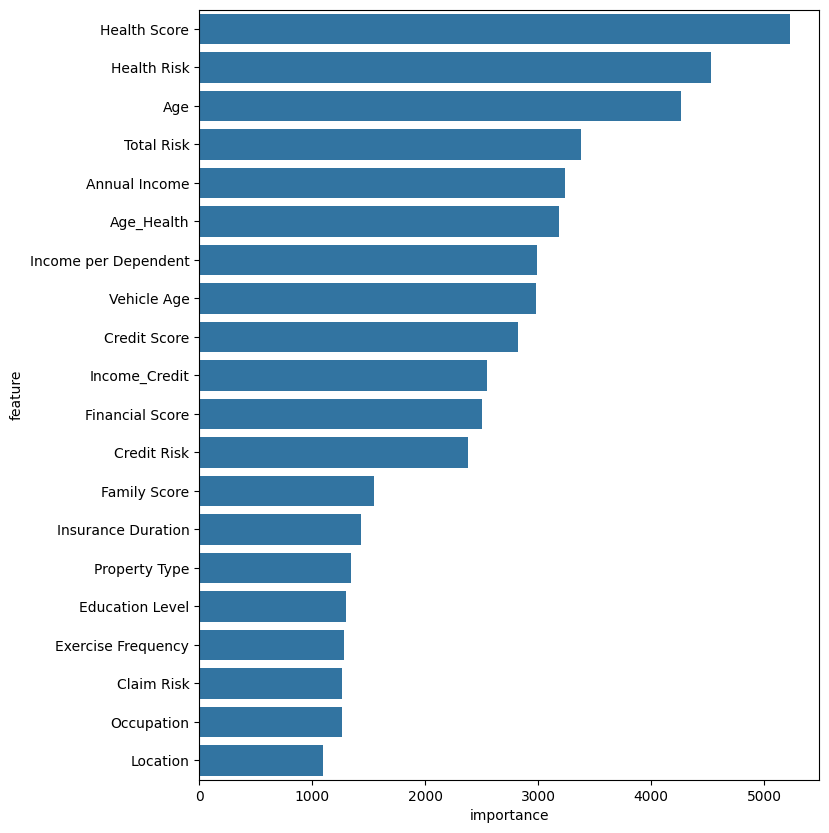

In [159]:
plt.figure(figsize=(8,10))
sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

In [160]:
test_pred = np.expm1(test_pred)

In [161]:
submission = pd.DataFrame({
    "id": test_ids,
    "Premium Amount": test_pred
})

submission.to_csv("submission.csv", index=False)